In [94]:
import pandas as pd
df= pd.read_csv('data.csv')
df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_min_latency,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.000012,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.000002,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.000019,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj,27,4.0,5.0,40.0,0.000013,0.872110,0.000008,0.050308,4.0,...,0.000002,0.060523,109,110,108,217,325,0.039513,0.976452,0.000054
4,dj,50,2.0,3.0,24.0,0.000021,0.873850,0.000014,0.149187,2.0,...,0.000005,0.162900,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,wstate,50,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,...,0.000029,0.291252,93,372,184,553,737,0.071815,0.958544,0.000061
613,wstate,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.000019,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061
614,wstate,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.000014,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063
615,wstate,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.000032,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063


In [2]:
feature = df[['name','width','depth','two_qubit_gate_num']].drop_duplicates()

In [3]:
feature.groupby('name').describe()['two_qubit_gate_num']

,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
dj,29.0,70.551724,38.946471,6.0,33.00,70.0,108.00,125.0
e,31.0,1759.419355,1295.695123,90.0,560.50,1595.0,2672.50,4194.0
gan,2.0,40.500000,36.062446,15.0,27.75,40.5,53.25,66.0
ghz,43.0,68.186047,35.246922,12.0,39.00,69.0,98.00,128.0
graphstate,42.0,67.428571,33.125145,13.0,40.50,69.5,92.50,129.0
hhl,2.0,1020.000000,704.278354,522.0,771.00,1020.0,1269.00,1518.0
hor__,1.0,8160.000000,NaN,8160.0,8160.00,8160.0,8160.00,8160.0
oa,2.0,50.000000,2.828427,48.0,49.00,50.0,51.00,52.0
peexact,17.0,1530.588235,1344.522781,16.0,577.00,1118.0,2591.00,3960.0


## latency

In [108]:
# 绘制Latency Speedup
valid_df= df[df['mip_num_cuts']>0]


In [109]:

valid_df = valid_df[valid_df.name.isin(valid_df.name.value_counts().index[0:-3])]

In [110]:
valid_df.name = valid_df.name.replace('oa','qaoa').replace('e','ae').replace('graphstate','graph').replace('gan','qgan').apply(lambda x: x.upper())

In [111]:
latency_df= valid_df
latency_df['mip_Latency']=latency_df['mip_Latency']*1e6
latency_df['basic_min_latency']=latency_df['basic_min_latency']*1e6


In [116]:
latency_df = latency_df.groupby(by=['name','qpu_width']).mean().reset_index()

In [118]:
import matplotlib.pyplot as plt
import numpy as np
## set dpi
plt.rcParams['figure.dpi'] = 600
## font size
plt.rcParams['font.size'] = 30
## font family
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(1,figsize=(25, 10))
colors = ["#F6BE7A","#B8A6D1"]
ax.bar(latency_df.index-0.15,latency_df['mip_Latency'],width=0.3,label='CutQC',color=colors[0])
ax.bar(latency_df.index+0.15,latency_df['basic_min_latency'],width=0.3,label='adaptivedqc',color=colors[1])
avgid = len(latency_df.index)+0.8
rect1  = ax.bar(avgid-0.15,round(latency_df['mip_Latency'].mean(),2),width=0.3,color=colors[0])
rect2  = ax.bar(avgid+0.15,round(latency_df['basic_min_latency'].mean(),2),width=0.3,color=colors[1])
ax.bar_label(rect1, padding=3)
ax.bar_label(rect2, padding=3)
ax.set_xticks(latency_df.index.to_list()+[avgid])
ax.set_xticklabels(latency_df.qpu_width.tolist()+['Average'])
ax.legend(frameon=False)
ax.grid(axis='y',linestyle='--',
            linewidth=0.5, color='gray', alpha=0.8)
ax.set_ylabel(r'Latency/$\mu s$',fontsize=35)

Text(0, 0.5, 'Latency/$\\mu s$')

In [2]:
## Latency Metric compare
import matplotlib.pyplot as plt
import numpy as np
## set dpi
plt.rcParams['figure.dpi'] = 600
## font size
plt.rcParams['font.size'] = 14
## font family
plt.rcParams['font.family'] = 'Times New Roman'
colours = ['#B199F9',
           "#E3BECA",
           "#F8C891",
           "#F7F2BC",
           "#E6ECF3",
           "#FBF5F7",
           '#B3C5DA',
           '#C3B6D9']
## 字体大小设置
plt.rc('font', family='Times New Roman', size=20)
## 设置x轴刻度 按照qpu_width和 name 分组
names = latency_df['name'].value_counts().sort_index().index.to_list()
x_label= latency_df['qpu_width'].value_counts().sort_index().index.to_list()
fig = plt.figure(figsize=(25, 10))
ax1 = fig.add_subplot(111)
# ##设置x轴的位置刻度
x_index = np.arange(len(x_label))
width = 0.8/len(names)
data_mean = latency_df.groupby(by=['qpu_width', 'name']).mean()[['Latency_Speedup','mip_QU','basic_QU']].reset_index(level=1)
data_max = latency_df.groupby(by=['qpu_width', 'name']).max()[[
    'Latency_Speedup','mip_QU','basic_QU']].reset_index(level=1)
data_min = latency_df.groupby(by=['qpu_width', 'name']).min()[[
    'Latency_Speedup','mip_QU','basic_QU']].reset_index(level=1)
# ax2 = ax1.twinx()  
for i in range(len(names)):
    d_min = data_min[data_min['name'] == names[i]][[
    'Latency_Speedup','mip_QU','basic_QU']]
    d_max = data_max[data_max['name'] == names[i]][[
        'Latency_Speedup','mip_QU','basic_QU']]
    d_mean = data_mean[data_mean['name'] == names[i]][[
        'Latency_Speedup','mip_QU','basic_QU']]
    d_max = d_max-d_mean
    d_min = d_mean-d_min
    d_mean = d_mean.reindex(x_label).sort_index()
    d_min = d_min.reindex(x_label).sort_index()
    d_max = d_max.reindex(x_label).sort_index()
    ax1.bar([x+width*i for x in x_index],d_mean['Latency_Speedup'],width=width,yerr=[d_min['Latency_Speedup'],d_max['Latency_Speedup']],ecolor=colours[4],label=names[i]+' Latency Speedup',alpha=0.9)
    # 绘制y=1的参考线
## 绘制平均值
all_mean = latency_df.mean()[['Latency_Speedup','mip_QU','basic_QU']]
rect = ax1.bar([len(x_label)],all_mean['Latency_Speedup'],width=width,label='Average Latency Speedup',color= colours[3],alpha=0.9)
ax1.bar_label(rect, padding=3)
data_mean = data_mean.reset_index()
## 设置多维索引保证 QPU width 都有 [5,10,16,27,50,65]
## 构造 name 和QPU width 的多维索引
Mu_index = pd.MultiIndex.from_product(
    [x_label, names], names=['qpu_width', 'name'])
data_mean = data_mean.set_index(['qpu_width', 'name']).reindex(Mu_index).sort_index()
    ## 绘制QU折线图
Mu_xs = [xi+width*i for xi in x_index for i in range(len(names))]
y1 = (data_mean['mip_QU']*100).to_list()
y2 = (data_mean['basic_QU']*100).to_list()
# ax2.scatter(Mu_xs,y1,marker='h',label="CutQC QU", color=colours[0])
# ax2.scatter(Mu_xs,y2,marker='^',label="adaptivedqc QU",color=colours[2])
# for i in range(len(Mu_xs)):
#     if y2[i] > y1[i]:
#         ax2.plot([Mu_xs[i], Mu_xs[i]], [y1[i], y2[i]], 'g-', lw=1)  # 绿线
#     else:
#         ax2.plot([Mu_xs[i], Mu_xs[i]], [y1[i], y2[i]], 'r-', lw=1)  # 红线
Avg_id = len(x_label)
Avg_data = [all_mean['mip_QU']*100,all_mean['basic_QU']*100]
# ax2.scatter([Avg_id],Avg_data[0],marker='h',s=10,color=colours[0])
# ax2.scatter([Avg_id],Avg_data[1],
#             marker='^',s=10, color=colours[2])
# ax2.annotate(f'{Avg_data[1]:.1f}', xy=(Avg_id,Avg_data[1]),
#              xytext=(Avg_id+0.1, Avg_data[1]))
# ax2.annotate(f'{Avg_data[0]:.1f}', xy=(Avg_id,Avg_data[0]),
#              xytext=(Avg_id+0.1, Avg_data[0]-1))
ax1.hlines(1,x_index.min()-0.1,x_index.max()+0.8,color='red', linestyles='dashed')
ax1.legend(loc=1,frameon=False)
ax1.set_ylabel('Latency Speedup/X')
x_index = np.append(x_index+0.3,len(x_label))
x_label.append('Average')
ax1.set_xticks(x_index, labels=x_label)
## 设置y轴刻度并设为虚线
ax1.set_yticks([0,1,10,20,30])
ax1.grid(axis='y',linestyle='--',
            linewidth=0.5, color='gray', alpha=0.2)
ax1.minorticks_on()
# ax2.legend(loc=2)
# ## 设置
# ax2.set_ylabel('QU/%',fontsize=18)
ax1.set_xlabel("QPU width",fontsize=18)
## 显示图形
plt.show()

/var/folders/yl/f78zmr7d24n8y70v98h117ww0000gn/T/ipykernel_17636/329684522.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['Latency_Speedup'] = valid_df['mip_Latency']/valid_df['basic_min_latency']
/var/folders/yl/f78zmr7d24n8y70v98h117ww0000gn/T/ipykernel_17636/329684522.py:54: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  all_mean = latency_df.mean()[['Latency_Speedup','mip_QU','basic_QU']]


## fidelity

In [85]:
valid_df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all,Latency_Speedup
0,DJ,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051,1.082645
1,DJ,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051,10.047619
2,DJ,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051,1.680628
3,DJ,27,4.0,5.0,40.0,0.000013,0.872110,0.000008,0.050308,4.0,...,0.060523,109,110,108,217,325,0.039513,0.976452,0.000054,6.000000
4,DJ,50,2.0,3.0,24.0,0.000021,0.873850,0.000014,0.149187,2.0,...,0.162900,109,110,108,217,325,0.039513,0.976452,0.000054,4.137255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,WSTATE,27,8.0,5.0,272.0,0.000017,0.866416,0.000010,0.072811,6.0,...,0.109502,93,372,184,553,737,0.071815,0.958544,0.000061,1.469298
613,WSTATE,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061,1.710938
614,WSTATE,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063,1.232143
615,WSTATE,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063,1.025357


In [86]:
fidelity_df= valid_df.groupby(by='name').mean()[['mip_Fidelity','error_Fidelity']].reset_index()
fidelity_df['mip_Error'] = (1-fidelity_df['mip_Fidelity'])*100
fidelity_df['error_Error'] = (1-fidelity_df['error_Fidelity'])*100

Text(0, 0.5, 'Average Error/%')

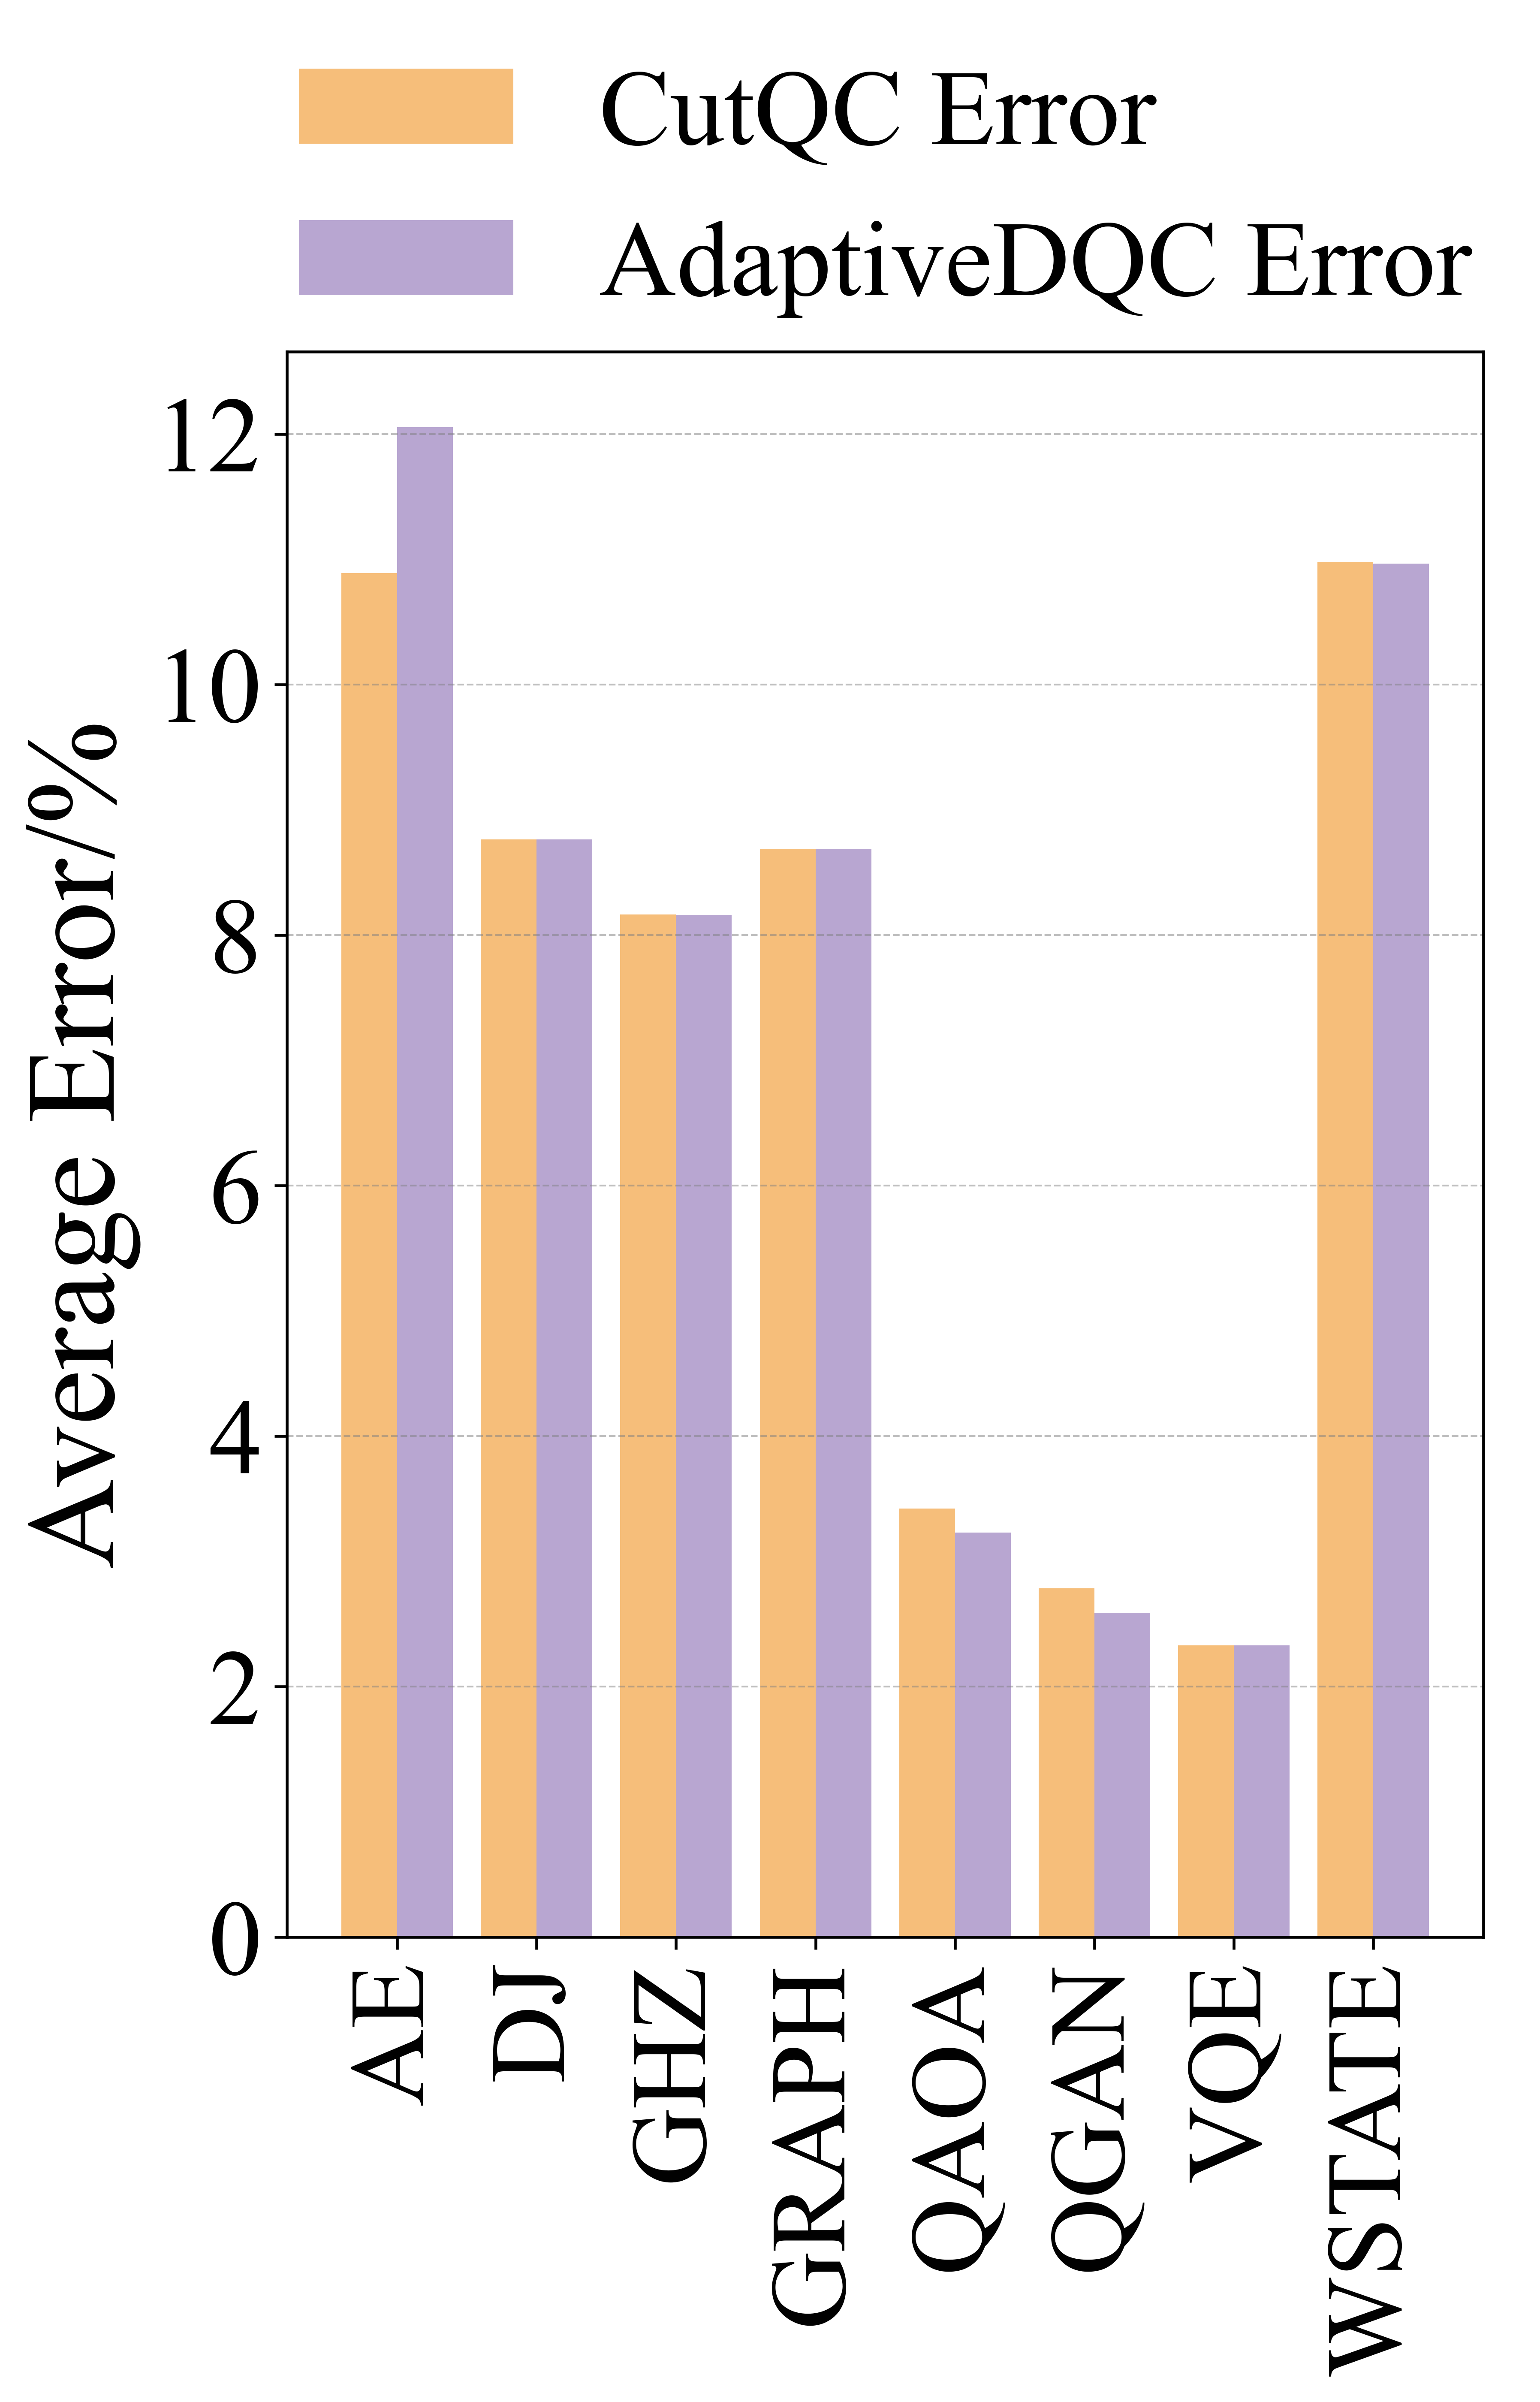

In [93]:
x = np.arange(len(fidelity_df['name']))
fig,ax = plt.subplots(figsize=(6, 10))
ax.set_xticks(x, labels=fidelity_df['name'])
colors = ["#F6BE7A","#B8A6D1"]
ax.bar(x-0.2,fidelity_df['mip_Error'],width=0.4,label='CutQC Error',color=colors[0])
ax.bar(x+0.2,fidelity_df['error_Error'],width=0.4,label='adaptivedqc Error',color=colors[1])
ax.grid(axis='y',linestyle='--',
            linewidth=0.5, color='gray', alpha=0.5)
## rotate the x axis labels
plt.setp(ax.get_xticklabels(), rotation=90)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width , box.height* 0.8])
ax.legend(loc='center', bbox_to_anchor=(0.5, 1.1),ncol=1,frameon=False)
# ax.set_xlabel('Benchmark',fontsize=35)
ax.set_ylabel('Average Error/%',fontsize=35)


## Dataflux

In [4]:
dataFlux_df = df[df['mip_DataFlux']>=df['basic_DataFlux']]

In [5]:
dataFlux_df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_min_latency,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.000012,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.000002,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.000019,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051
4,dj,50,2.0,3.0,24.0,0.000021,0.873850,0.000014,0.149187,2.0,...,0.000005,0.162900,109,110,108,217,325,0.039513,0.976452,0.000054
5,dj,65,1.0,2.0,8.0,0.000032,0.874716,0.000022,0.271013,1.0,...,0.000022,0.271013,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,wstate,27,8.0,5.0,272.0,0.000017,0.866416,0.000010,0.072811,6.0,...,0.000011,0.109502,93,372,184,553,737,0.071815,0.958544,0.000061
613,wstate,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.000019,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061
614,wstate,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.000014,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063
615,wstate,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.000032,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063


In [6]:
dataFlux_df= dataFlux_df.groupby(by=['name','qpu_width']).mean()[['mip_DataFlux','basic_DataFlux']].reset_index()
dataFlux_df= dataFlux_df[dataFlux_df['mip_DataFlux']>0]


In [7]:
dataFlux_df = dataFlux_df[dataFlux_df['name']!= 'peexact'][dataFlux_df['name']!= 'routing'][dataFlux_df['name']!= 'tsp']
dataFlux_df.reset_index(drop=True,inplace=True)

/var/folders/yl/f78zmr7d24n8y70v98h117ww0000gn/T/ipykernel_96487/4252254681.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dataFlux_df = dataFlux_df[dataFlux_df['name']!= 'peexact'][dataFlux_df['name']!= 'routing'][dataFlux_df['name']!= 'tsp']


In [8]:
dataFlux_df

,name,qpu_width,mip_DataFlux,basic_DataFlux
0,dj,5,2.266667e+01,2.266667e+01
1,dj,10,3.714286e+01,3.714286e+01
2,dj,16,2.254545e+01,2.254545e+01
3,dj,27,2.210526e+01,2.210526e+01
4,dj,50,1.642105e+01,1.642105e+01
5,dj,65,8.000000e+00,8.000000e+00
6,e,10,1.048576e+06,1.048576e+06
7,e,16,4.294967e+09,1.048576e+06
8,e,27,8.830453e+12,1.048576e+06
9,gan,5,1.024000e+03,1.024000e+03


In [10]:
## 采用对数坐标绘制数据通量的比较图

## Latency Metric compare
import matplotlib.pyplot as plt
import numpy as np
## set dpi
plt.rcParams['figure.dpi'] = 600
## font size
plt.rcParams['font.size'] = 30
## font family
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(1,figsize=(30, 10))
colors = ["#F6BE7A","#B8A6D1"]
ax.bar(dataFlux_df.index,dataFlux_df['mip_DataFlux'],width=0.3,label='CutQC',color=colors[0])
ax.bar(dataFlux_df.index+0.3,dataFlux_df['basic_DataFlux'],width=0.3,label='adaptivedqc',color=colors[1])
ax.set_yscale("log", base = 10)
# ax.set_xticks(dataFlux_df.index, minor=True)
# ax.set_xticklabels(dataFlux_df.width, minor=True)
ax.set_xticks(dataFlux_df.index+0.3/2)
ax.set_xticklabels(dataFlux_df.qpu_width)
ax.set_xlim(-0.5, len(dataFlux_df.index)-0.2)
ax.set_ylabel('Data Flux',fontsize=35)
plt.legend(frameon=False)


In [108]:
## 采用对数坐标绘制数据通量的比较图
## Latency Metric compare
import matplotlib.pyplot as plt
import numpy as np
## set dpi
plt.rcParams['figure.dpi'] = 600
## font size
plt.rcParams['font.size'] = 20
## font family
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(25, 10))
colors = ["#F6BE7A","#B8A6D1"]
## 设置颜色,颜色数量要与数据量相同
## 使用内置的颜色表
x_index = np.arange(len(x_label))
width = 0.8/len(names)
for i,name in enumerate(dataFlux_df['name'].unique()):
    data = dataFlux_df[dataFlux_df['name']==name]
    plt.plot(data['width'],data['mip_DataFlux'],'--',linewidth=1,color=colors[i])
    plt.plot(data['width'],data['basic_DataFlux'],'-',linewidth=1,color=colors[i],label=name)

plt.legend()
plt.xlabel('width')
plt.ylabel('log2(DataFlux)')

Text(0, 0.5, 'log2(DataFlux)')